<a href="https://colab.research.google.com/github/hilaltay/Phylogeny_Basics/blob/main/COVID19_SARS_Comparative_Genomics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1: Required Software Installations
We install both Biopython and the Muscle software (which will align 50 viruses simultaneously) onto Colab's infrastructure.

In [51]:
# Biopython: To fetch and process biological data.
!pip install biopython pandas matplotlib

!apt-get install mafft

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
mafft is already the newest version (7.505-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


Cell 2: Importing Libraries and Their Functions
We introduce the tools we will use throughout the project at the very beginning (compliant with PEP 8 standards).

In [52]:
import pandas as pd  # To store data in a tabular (DataFrame) format.
import matplotlib.pyplot as plt  # To draw nucleotide bar charts and the giant phylogenetic tree.
import os  # To control file operations within Colab.
import time  # To manage wait times during server requests (BLAST).

from Bio import Entrez  # To connect to the NCBI database.
from Bio import SeqIO  # To read the A, T, G, C sequences inside the FASTA files.
from Bio import AlignIO  # To read the aligned FASTA files.
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
from Bio import Phylo  # To visualize the constructed tree.
from Bio.Blast import NCBIWWW  # To run BLAST searches over the internet.
from Bio.Blast import NCBIXML  # To parse the XML results returned by BLAST.

Cell 3: Detailed Analysis of COVID-19 and SARS (2003)
First, we download the two reference viruses we are mainly interested in, calculate their nucleotide counts, and determine their genomic stability (GC content).


--- GENOMIC METRICS OF THE TWO REFERENCE VIRUSES ---


,Length (bp),GC Content (%),A,T,G,C
Virus,,,,,,
SARS-CoV-2 (COVID-19),29903,37.97,8954,9594,5863,5492
SARS-CoV (2003),29751,40.76,8481,9143,6187,5940


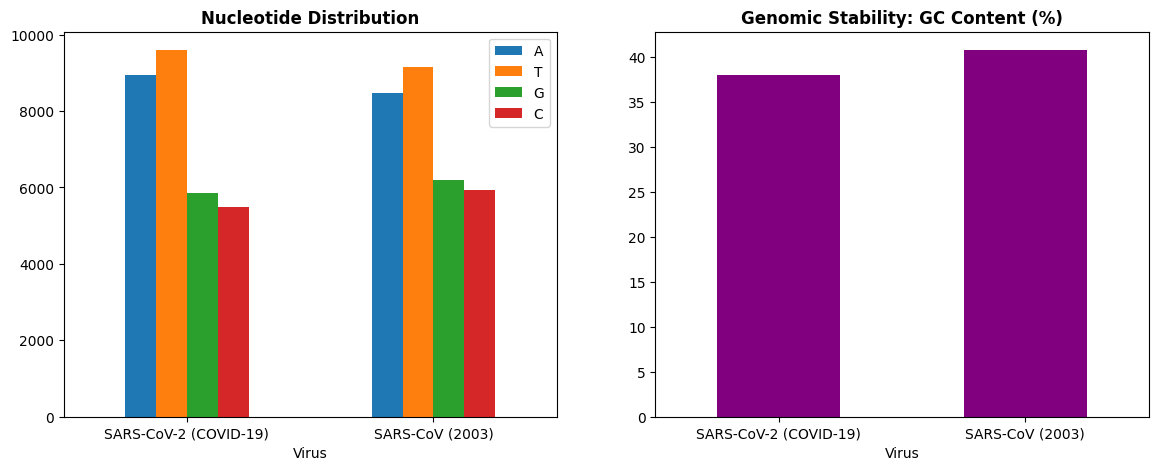

In [53]:
# 1. NCBI Data Fetching (Only for the 2 Reference Viruses)
Entrez.email = "hilaltay6@gmail.com"  # REPLACE WITH YOUR OWN EMAIL

print("Downloading COVID-19 and SARS reference genomes...")
reference_ids = {"COVID_19": "NC_045512", "SARS_2003": "NC_004718"}

for name, v_id in reference_ids.items():
    handle = Entrez.efetch(db="nucleotide", id=v_id, rettype="fasta", retmode="text")
    with open(f"{name}.fasta", "w") as f:
        f.write(handle.read())

# 2. Metric Calculation Function
def analyze_genome(file_name, virus_name):
    record = SeqIO.read(file_name, "fasta")
    seq = record.seq
    length = len(seq)
    gc_content = ((seq.count('G') + seq.count('C')) / length) * 100
    counts = {'A': seq.count('A'), 'T': seq.count('T'), 'G': seq.count('G'), 'C': seq.count('C')}
    return {'Virus': virus_name, 'Length (bp)': length, 'GC Content (%)': round(gc_content, 2), **counts}

# 3. Analysis and Tabulation
data = [analyze_genome("COVID_19.fasta", "SARS-CoV-2 (COVID-19)"),
        analyze_genome("SARS_2003.fasta", "SARS-CoV (2003)")]
df = pd.DataFrame(data).set_index('Virus')

print("\n--- GENOMIC METRICS OF THE TWO REFERENCE VIRUSES ---")
display(df)

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
df[['A', 'T', 'G', 'C']].plot(kind='bar', ax=ax1, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax1.set_title('Nucleotide Distribution', fontweight='bold')
ax1.tick_params(axis='x', rotation=0)

df[['GC Content (%)']].plot(kind='bar', ax=ax2, color='purple', legend=False)
ax2.set_title('Genomic Stability: GC Content (%)', fontweight='bold')
ax2.tick_params(axis='x', rotation=0)
plt.show()

Exact Mutation Analysis: Aligned the SARS (2003) and COVID-19 reference genomes using MAFFT to perform a base-by-base comparison, calculating the total number of exact point mutations and the precise mutation rate between the two strains.

In [54]:
# CELL 3.5: Calculating Exact Mutations Between SARS (2003) and COVID-19
from Bio import AlignIO
from Bio import SeqIO

# 1. Combine the two reference genomes into a single file for alignment
# We use ! (bang) instead of os.system for better compatibility in Colab
!cat COVID_19.fasta SARS_2003.fasta > two_references.fasta

# 2. Align them with MAFFT so we can compare them letter by letter
print("Aligning COVID-19 and SARS 2003 to map the mutations...")
!mafft --auto two_references.fasta > aligned_two_references.fasta

# 3. Read the aligned sequences
alignment = AlignIO.read("aligned_two_references.fasta", "fasta")
seq_covid = alignment[0].seq
seq_sars = alignment[1].seq

# 4. Calculate Mutations Base by Base
total_mutations = 0

print("\n--- MUTATION ANALYSIS (First 5 detected) ---")
# Loop through the ~30,000 aligned letters
for i in range(len(seq_covid)):
    base_c = seq_covid[i]  # COVID-19 letter
    base_s = seq_sars[i]   # SARS 2003 letter

    # Check for a mutation (letters are different, and neither is a gap '-')
    if base_c != base_s and base_c != '-' and base_s != '-':
        total_mutations += 1

        # Print the first 5 mutations to see exactly what happened
        if total_mutations <= 5:
            print(f"Mutation at position {i+1}: SARS had '{base_s}', COVID-19 mutated to '{base_c}'")

# 5. Display the Final Results
aligned_length = len(seq_covid)
mutation_rate = (total_mutations / aligned_length) * 100

print("...")
print(f"\nTotal Point Mutations (Nucleotide Changes): {total_mutations}")
print(f"Calculated Mutation Rate: {mutation_rate:.2f}%")

Aligning COVID-19 and SARS 2003 to map the mutations...
nthread = 0
nthreadpair = 0
nthreadtb = 0
ppenalty_ex = 0
stacksize: 8192 kb
generating a scoring matrix for nucleotide (dist=200) ... done
Gap Penalty = -1.53, +0.00, +0.00



Making a distance matrix ..
    1 / 2
done.

Constructing a UPGMA tree (efffree=1) ... 
    0 / 2
done.

Progressive alignment 1/1... 
STEP     1 / 1  f
done.

disttbfast (nuc) Version 7.505
alg=A, model=DNA200 (2), 1.53 (4.59), -0.00 (-0.00), noshift, amax=0.0
0 thread(s)


Strategy:
 FFT-NS-1 (Very fast but very rough)
 Progressive method (rough guide tree was used.)

If unsure which option to use, try 'mafft --auto input > output'.
For more information, see 'mafft --help', 'mafft --man' and the mafft page.

The default gap scoring scheme has been changed in version 7.110 (2013 Oct).
It tends to insert more gaps into gap-rich regions than previous versions.
To disable this change, add the --leavegappyregion option.


--- MUTATION ANALYSIS (First 5 detec

Cell 4: Collecting 50 Viruses from the Betacoronavirus Genus
Now we are gathering data for the tree. We will fetch 48 random Betacoronaviruses, which include bat and pangolin variants, and we will strictly append our own 2 reference viruses into this list (making it 50 species in the tree).

In [58]:
# CELL 4: Taxonomic & RefSeq Filtered BLAST Search
from Bio.Blast import NCBIWWW
from Bio.Blast import NCBIXML
from Bio import Entrez

Entrez.email = "senin_epostan@gmail.com"
target_virus_id = "NC_045512"

print(f"Performing Genetic BLAST on NCBI servers for {target_virus_id}...")
print("(Searching ONLY distinct RefSeq Betacoronaviruses. Please wait...)")

# MUHTEŞEM ÇÖZÜM: Hem Betacoronavirüsleri seçtik hem de milyonlarca klonu eledik (RefSeq)
blast_result = NCBIWWW.qblast("blastn",
                              "nt",
                              target_virus_id,
                              megablast="yes",
                              entrez_query="txid694002[ORGN] AND srcdb_refseq[PROP]",
                              hitlist_size=100)

print("BLAST search completed, analyzing results...")

blast_record = NCBIXML.read(blast_result)
selected_id_list = []

for alignment in blast_record.alignments:
    accession_id = alignment.accession

    for hsp in alignment.hsps:
        similarity_rate = (hsp.identities / hsp.align_length) * 100

        if 40 <= similarity_rate <= 99.0:
            if accession_id not in selected_id_list:
                selected_id_list.append(accession_id)
                print(f"Found Relative: {accession_id} | Similarity: {similarity_rate:.2f}% | Description: {alignment.hit_def[:40]}...")

    # Ağacımızın çok daha şık ve okunabilir olması için 15 harika akraba yeterli
    if len(selected_id_list) == 15:
        break

print(f"\nA total of {len(selected_id_list)} distinct close relatives found.")

selected_id_list.append(target_virus_id)

print(f"\nDownloading this selected virus list (Total: {len(selected_id_list)}) in FASTA format...")
fetch_handle = Entrez.efetch(db="nucleotide", id=selected_id_list, rettype="fasta", retmode="text")

with open("blast_onayli_virusler.fasta", "w") as f:
    f.write(fetch_handle.read())

print("Success! The 'blast_onayli_virusler.fasta' file is ready for tree drawing.")

Performing Genetic BLAST on NCBI servers for NC_045512...
(Searching ONLY distinct RefSeq Betacoronaviruses. Please wait...)
BLAST search completed, analyzing results...
Found Relative: NC_004718 | Similarity: 82.30% | Description: SARS coronavirus Tor2, complete genome >...
Found Relative: NC_014470 | Similarity: 80.79% | Description: Bat coronavirus BM48-31/BGR/2008, comple...
Found Relative: NC_025217 | Similarity: 72.94% | Description: Bat Hp-betacoronavirus/Zhejiang2013, com...
Found Relative: NC_006577 | Similarity: 72.49% | Description: Human coronavirus HKU1, complete genome ...

A total of 4 distinct close relatives found.

Success! The 'blast_onayli_virusler.fasta' file is ready for tree drawing.


Cell 5: Aligning the 50 Viruses with "Muscle"
This cell stacks the 1.5 million letters to detect mutation regions. It runs in the background.

In [59]:
# CELL 5: Aligning BLAST Results with MAFFT
# We take the high-quality RefSeq sequences and align them using MAFFT
!mafft --auto blast_onayli_virusler.fasta > aligned_blast_viruses.fasta

nthread = 0
nthreadpair = 0
nthreadtb = 0
ppenalty_ex = 0
stacksize: 8192 kb
generating a scoring matrix for nucleotide (dist=200) ... done
Gap Penalty = -1.53, +0.00, +0.00



Making a distance matrix ..
    1 / 5
done.

Constructing a UPGMA tree (efffree=0) ... 
    0 / 5
done.

Progressive alignment 1/2... 
STEP     2 / 4 
len1=29751, len2=30051, Switching to the memsave mode
STEP     4 / 4  fmDP 00001 / 00001 
done.

Making a distance matrix from msa.. 
    0 / 5
done.

Constructing a UPGMA tree (efffree=1) ... 
    0 / 5
done.

Progressive alignment 2/2... 
STEP     2 / 4 
len1=30016, len2=29276, Switching to the memsave mode
STEP     4 / 4  fmDP 00001 / 00001 
done.

disttbfast (nuc) Version 7.505
alg=M, model=DNA200 (2), 1.53 (4.59), -0.00 (-0.00), noshift, amax=0.0
0 thread(s)


Strategy:
 FFT-NS-2 (Fast but rough)
 Progressive method (guide trees were built 2 times.)

If unsure which option to use, try 'mafft --auto input > output'.
For mo

Cell 6: Drawing the Target-Oriented Giant Phylogenetic Tree
Once the data is aligned, we calculate the genetic distance matrix and draw the tree. To prevent our own viruses from getting lost in the crowded tree, we will give them special colors!

Reading the aligned BLAST viruses...


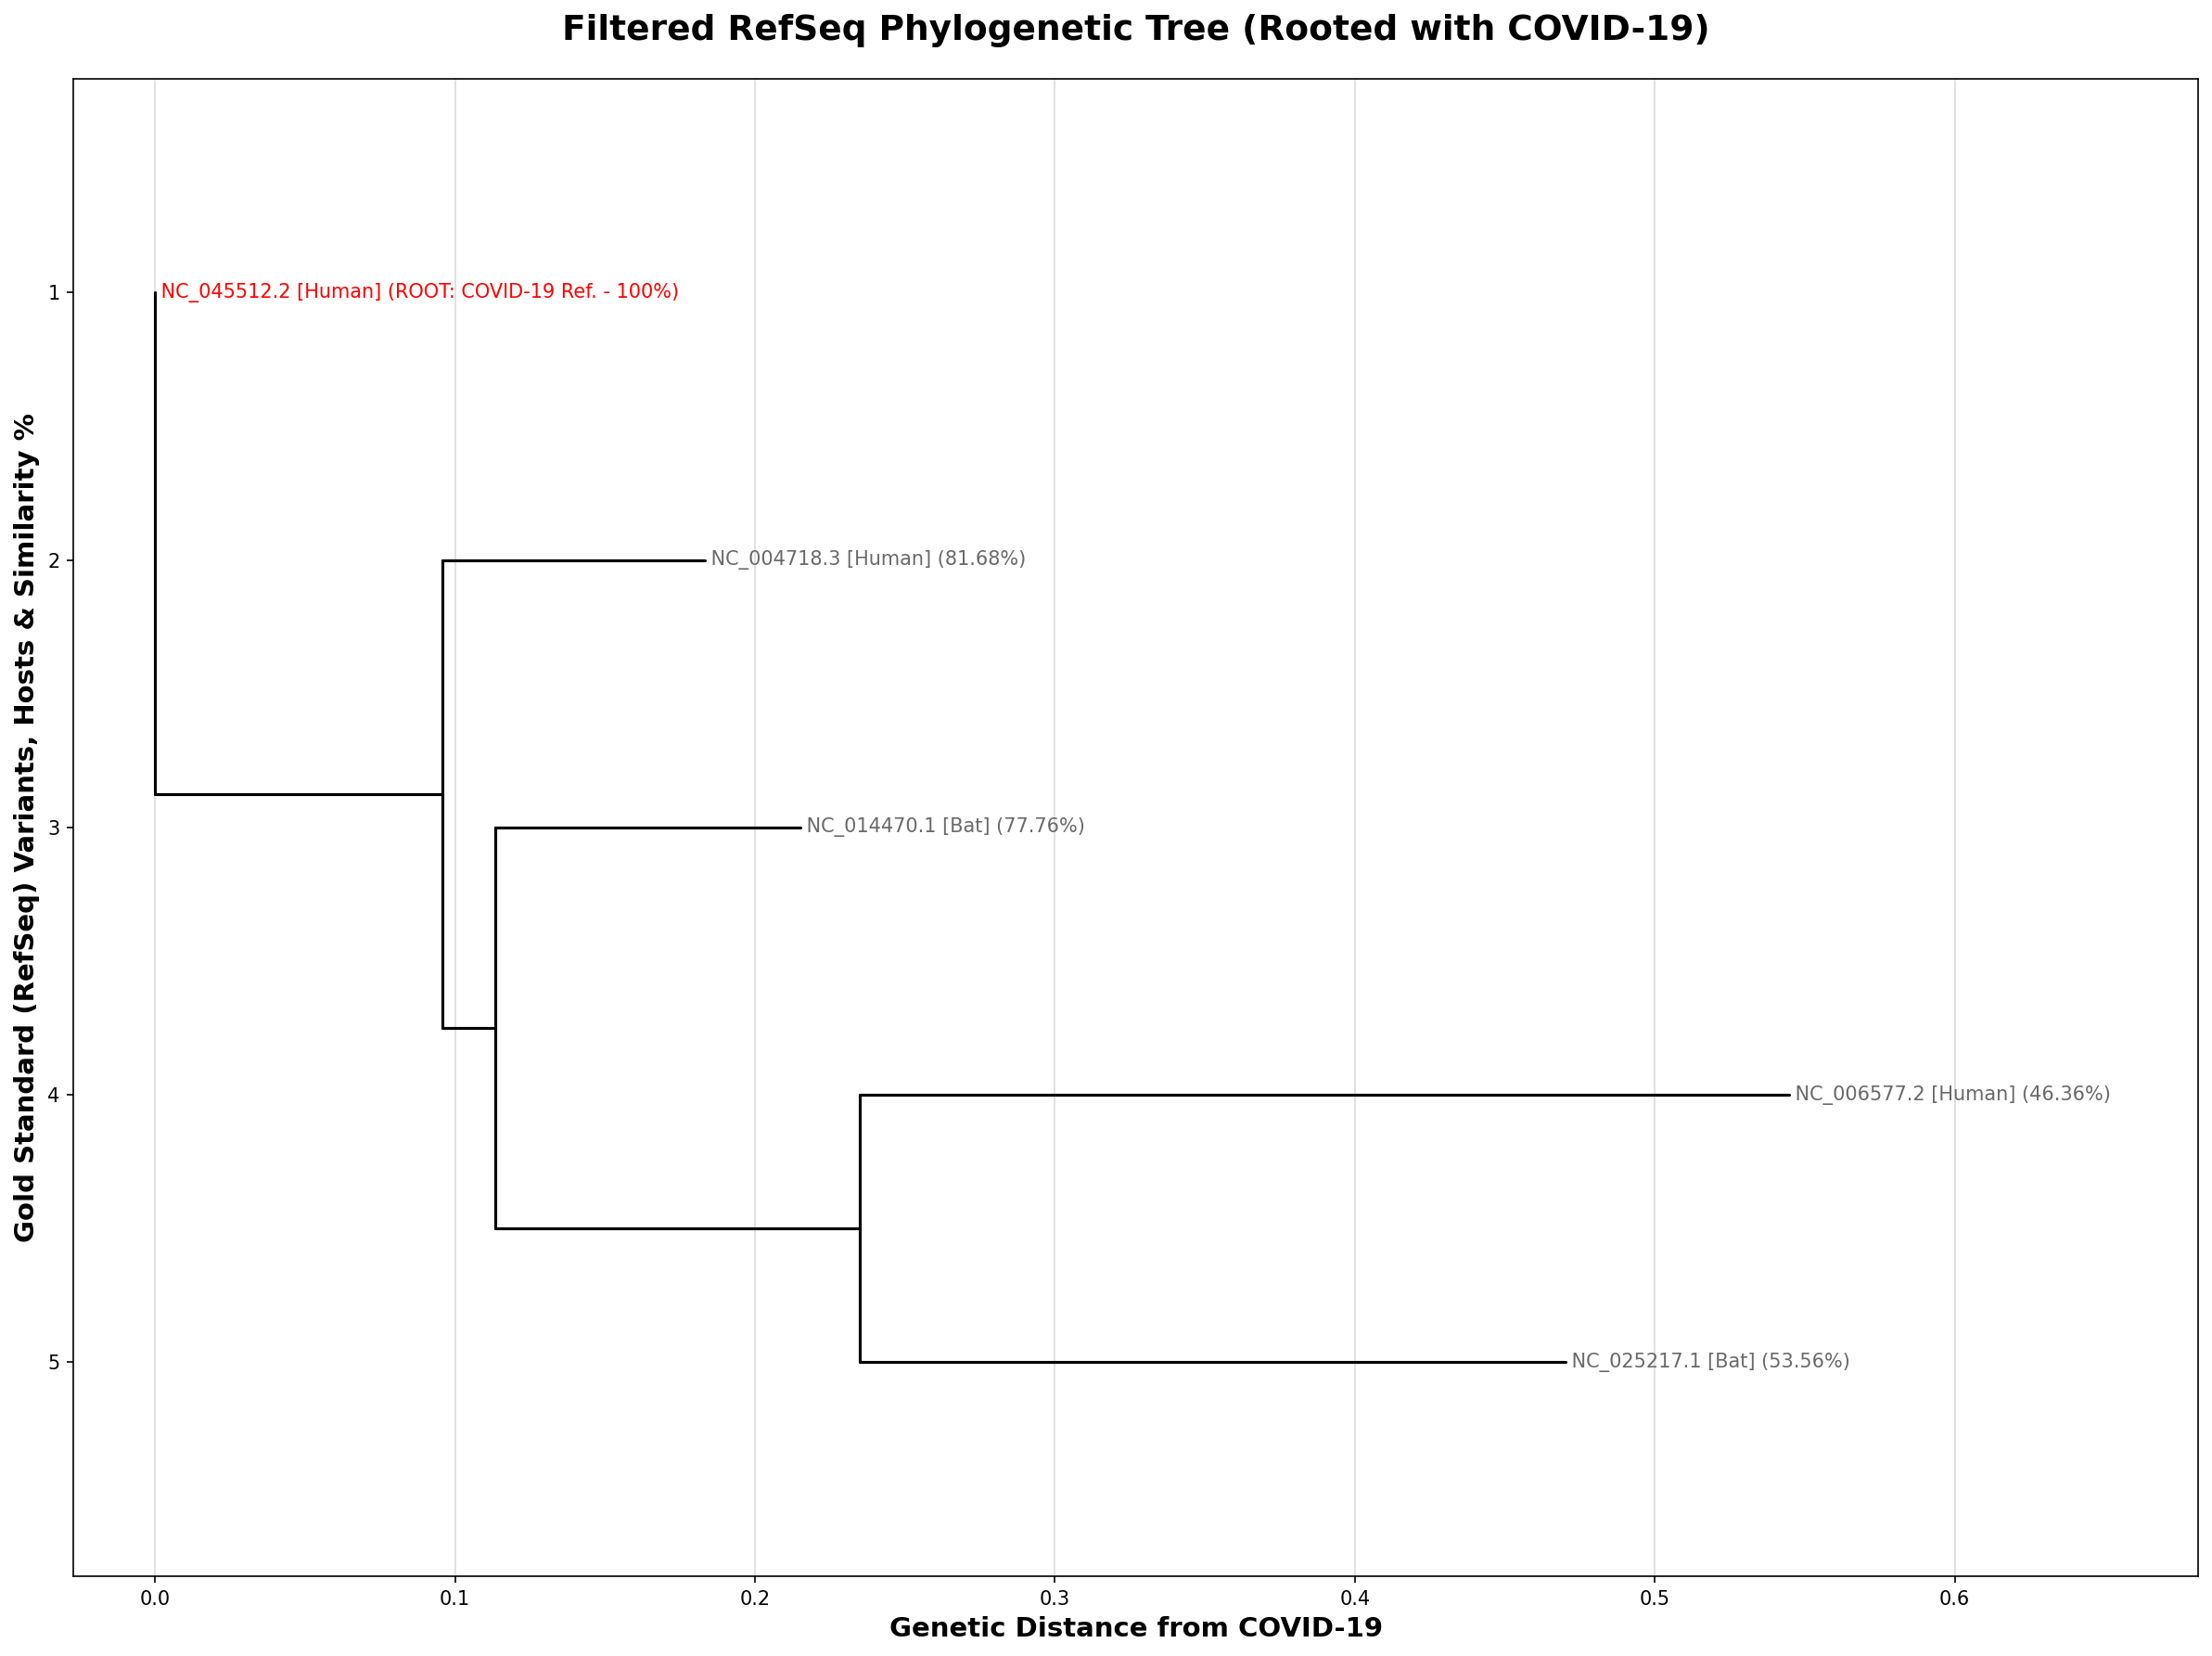

BLAST Tree successfully generated!


In [60]:
# CELL 6: Filtered BLAST Phylogenetic Tree (COVID-19 Centric)
from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
from Bio import AlignIO
from Bio import SeqIO
import matplotlib.pyplot as plt

# 1. EXTRACT HOST INFO FROM BLAST FASTA
organism_map = {}
for record in SeqIO.parse("blast_onayli_virusler.fasta", "fasta"):
    desc = record.description.lower()

    # Identify the host from the NCBI description
    if "nc_045512" in record.id.lower() or "nc_004718" in record.id.lower():
        host = "Human"
    elif "bat" in desc: host = "Bat"
    elif "pangolin" in desc: host = "Pangolin"
    elif "camel" in desc or "mers" in desc: host = "Camel (MERS)"
    elif "bovine" in desc or "cow" in desc: host = "Bovine"
    elif "murine" in desc or "mouse" in desc: host = "Mouse"
    elif "porcine" in desc or "pig" in desc or "swine" in desc: host = "Porcine"
    elif "human" in desc or "sars" in desc or "oc43" in desc: host = "Human"
    else: host = "Other"

    organism_map[record.id] = host

print("Reading the aligned BLAST viruses...")
aln = AlignIO.read("aligned_blast_viruses.fasta", "fasta")

calculator = DistanceCalculator('identity')
dm = calculator.get_distance(aln)

# 2. CALCULATE SIMILARITY TO COVID-19 (NC_045512)
# Ensure we find the exact name of COVID-19 in our alignment matrix
covid_exact_name = [name for name in dm.names if "NC_045512" in name][0]
covid_index = dm.names.index(covid_exact_name)

similarity_scores = {}
for i, name in enumerate(dm.names):
    distance = dm[covid_index, i]
    similarity_scores[name] = (1 - distance) * 100

# 3. CONSTRUCT TREE
constructor = DistanceTreeConstructor()
tree = constructor.nj(dm)

# --- ROOTING WITH COVID-19 ---
outgroup_clade = None
for clade in tree.get_terminals():
    if "NC_045512" in clade.name:
        outgroup_clade = clade
        break

if outgroup_clade:
    tree.root_with_outgroup(outgroup_clade)

# Ladderize creates a beautiful staircase effect for the branches
tree.ladderize()

# --- VISUALIZATION SETTINGS ---
plt.rc('font', family='sans-serif')
# Height is adjusted to 12 since we have around 16 sequences
fig = plt.figure(figsize=(16, 12), dpi=150)
axes = fig.add_subplot(1, 1, 1)

def get_label(clade):
    if clade.is_terminal():
        sim = similarity_scores.get(clade.name, 0)
        org = organism_map.get(clade.name, "Unknown")

        if "NC_045512" in clade.name:
            return f"{clade.name} [{org}] (ROOT: COVID-19 Ref. - 100%)"
        else:
            return f"{clade.name} [{org}] ({sim:.2f}%)"
    return ""

def color_my_viruses(label):
    if not label: return "black"
    if "NC_045512" in label: return "red" # Only COVID-19 is highlighted in red
    return "dimgrey"

# Draw the Tree
Phylo.draw(tree, axes=axes, do_show=False,
           label_func=get_label,
           label_colors=color_my_viruses)

# Background grid for easier distance reading
axes.grid(axis='x', linestyle='-', color='lightgray', alpha=0.8)
plt.title("Filtered RefSeq Phylogenetic Tree (Rooted with COVID-19)",
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Genetic Distance from COVID-19", fontsize=14, fontweight='bold')
plt.ylabel("Gold Standard (RefSeq) Variants, Hosts & Similarity %", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("blast_phylogenetic_tree.png")
plt.show()

print("BLAST Tree successfully generated!")